# Sector Benchmarks — Presentation Graphs

Selected graphs for iO Digital presentation.  
Data: 605 organisations, 17 sectors, 323M sessions (Jan–Apr 2026).  
Deep-dive sector: **food_beverage** (34 accounts).

---

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import numpy as np
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

try:
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

C = {
    'primary': '#0000D2',
    'secondary': '#365FD9',
    'accent': '#747474',
    'success': '#0000D2',
    'dark': '#242424',
    'light_grey': '#F4F4F4',
    'mid_grey': '#747474',
    'warning': '#C3D1CE',
    'reliable': '#0000D2',
    'caution': '#365FD9',
    'unreliable': '#747474',
}

io_cmap = LinearSegmentedColormap.from_list('io_blue', ['#F4F4F4', '#C3D1CE', '#365FD9', '#0000D2'])
io_cmap_warm = LinearSegmentedColormap.from_list('io_warm', ['#F4F4F4', '#DCCFC2', '#365FD9', '#0000D2'])

DB = Path('../data/ga4_data_lucas_final.db')
conn = sqlite3.connect(DB)

# Base KPI data (used by drill-down)
df_kpi = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        COUNT(DISTINCT p.account_id) AS accounts,
        SUM(d.sessions) AS sessions,
        SUM(d.engaged_sessions) AS engaged_sessions,
        AVG(d.bounce_rate) AS avg_bounce
    FROM properties p
    JOIN daily_summary d USING (property_id)
    WHERE p.is_active = 1 AND p.sector != 'unknown'
    GROUP BY p.sector
    ORDER BY sessions DESC
""", conn)
df_kpi['sessions_per_account'] = df_kpi['sessions'] / df_kpi['accounts']
df_kpi['eng_rate'] = df_kpi['engaged_sessions'] / df_kpi['sessions'] * 100


# Geographic data (used by drill-down)
df_geo = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        g.country,
        SUM(g.sessions) AS sessions
    FROM geo_device g
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
      AND g.country != '(not set)'
    GROUP BY sector, g.country
""", conn)


## 1. Dataset Overview

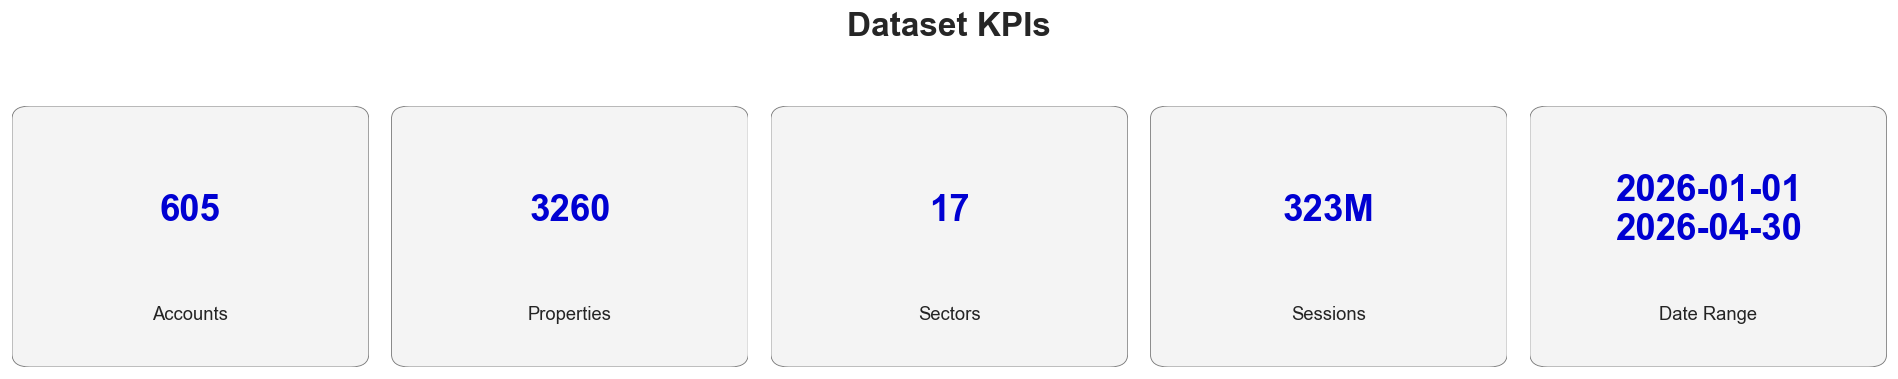

In [2]:
# 1.1 KPI Header — replaces the funnel diagram
date_range = pd.read_sql('SELECT MIN(date) as min_d, MAX(date) as max_d FROM daily_summary', conn)
n_accounts = pd.read_sql("SELECT COUNT(DISTINCT account_id) FROM properties WHERE is_active=1 AND sector != 'unknown'", conn).iloc[0, 0]
n_sectors = pd.read_sql("SELECT COUNT(DISTINCT sector) FROM properties WHERE is_active=1 AND sector NOT IN ('unknown','other')", conn).iloc[0, 0]
total_sessions = pd.read_sql('SELECT SUM(sessions) FROM daily_summary', conn).iloc[0, 0]
n_properties = pd.read_sql("SELECT COUNT(DISTINCT property_id) FROM properties WHERE is_active=1", conn).iloc[0, 0]

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
kpis = [
    (f'{n_accounts}', 'Accounts'),
    (f'{n_properties}', 'Properties'),
    (f'{n_sectors}', 'Sectors'),
    (f'{total_sessions/1e6:.0f}M', 'Sessions'),
    (f"{date_range['min_d'][0]}\n{date_range['max_d'][0]}", 'Date Range'),
]
for ax, (value, label) in zip(axes, kpis):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=22, fontweight='bold', color=C['primary'])
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=11, color=C['dark'])
    ax.add_patch(FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle='round,pad=0.05',
                                facecolor=C['light_grey'], edgecolor=C['mid_grey'], linewidth=0.5))

fig.suptitle('Dataset KPIs', fontweight='bold', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

## 2. Accounts per Sector

Betrouwbaarheid: blauw (n≥20) = betrouwbaar, lichtblauw (n=10-19) = voorzichtig, grijs (n<10) = onbetrouwbaar.

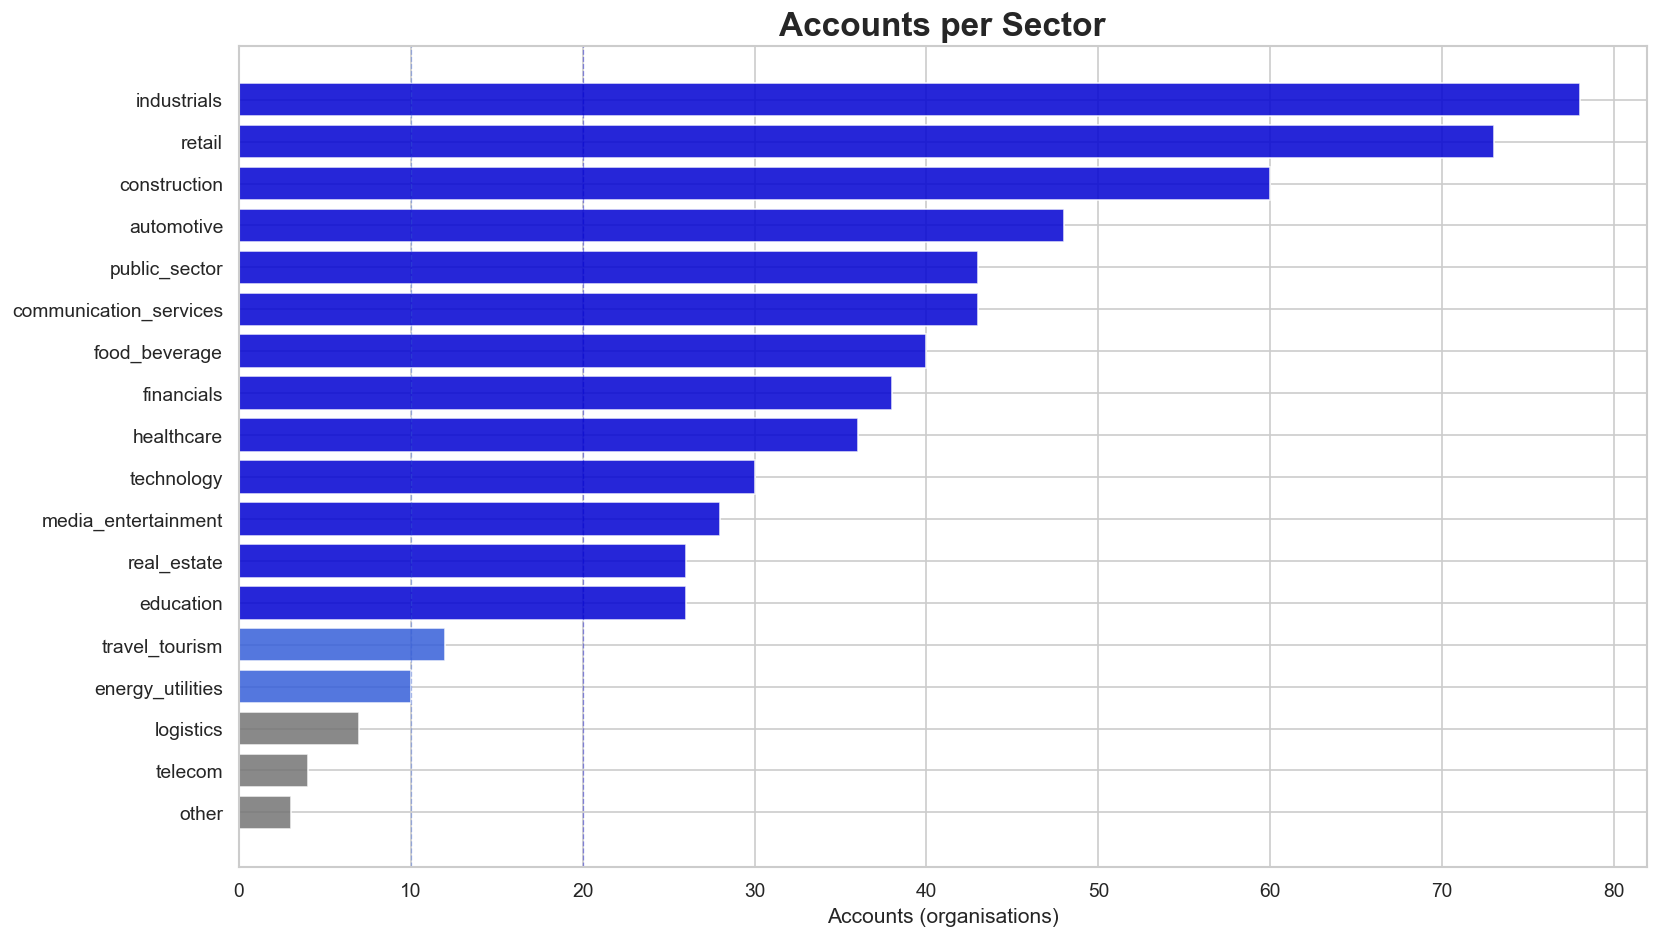


✅ Reliable sectors (n≥20): 13 of 18
   industrials, retail, construction, automotive, public_sector, communication_services, food_beverage, financials, healthcare, technology, media_entertainment, real_estate, education


In [3]:
# 1.2 Accounts per Sector with Reliability Indicator
df_portfolio = pd.read_sql("""
    SELECT 
        COALESCE(sector, 'other') AS sector,
        COUNT(DISTINCT account_id) AS accounts,
        COUNT(DISTINCT property_id) AS properties
    FROM properties
    WHERE is_active = 1 AND sector != 'unknown'
    GROUP BY sector
    ORDER BY accounts DESC
""", conn)

def reliability_label(n):
    if n >= 20: return 'reliable', C['reliable']
    if n >= 10: return 'moderate', C['caution']
    return 'unreliable', C['unreliable']

fig, ax = plt.subplots(figsize=(14, 8))
colors = [reliability_label(n)[1] for n in df_portfolio['accounts']]
bars = ax.barh(range(len(df_portfolio)), df_portfolio['accounts'], color=colors, alpha=0.85)
ax.set_yticks(range(len(df_portfolio)))
ax.set_yticklabels(df_portfolio['sector'])
ax.invert_yaxis()
ax.set_xlabel('Accounts (organisations)')
ax.set_title('Accounts per Sector',
             fontweight='bold', fontsize=20)

for bar, row in zip(bars, df_portfolio.itertuples()):
    reliability, _ = reliability_label(row.accounts)


ax.axvline(x=20, color=C['reliable'], linewidth=0.8, linestyle='--', alpha=0.4)
ax.axvline(x=10, color=C['caution'], linewidth=0.8, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

reliable = df_portfolio[df_portfolio['accounts'] >= 20]['sector'].tolist()
print(f"\n\u2705 Reliable sectors (n\u226520): {len(reliable)} of {len(df_portfolio)}")
print(f"   {', '.join(reliable)}")

/var/folders/px/j8znj30s2j51p2v9hxzhdp2r0000gp/T/ipykernel_30560/1770724480.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats = df_conc.groupby('sector').apply(sector_stats).sort_values('total_sessions', ascending=True)


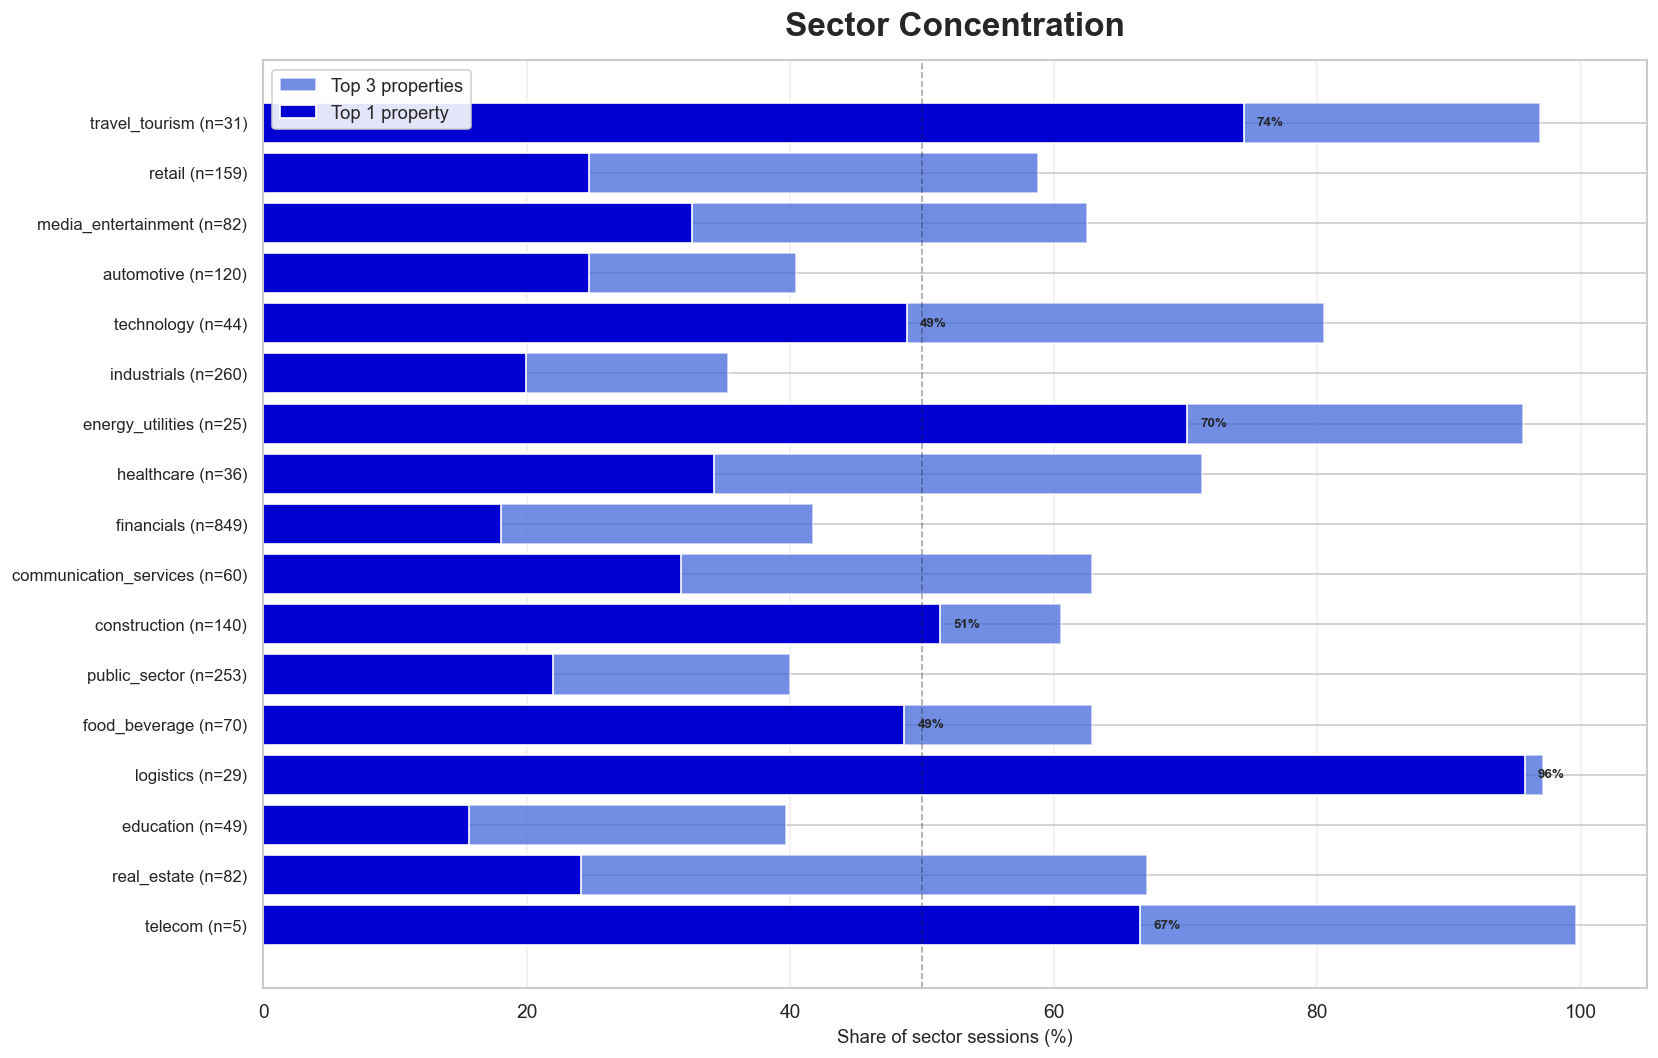

In [4]:
# 2b. Sector Concentration: Top-1 + Top-3 Property Share
# Shows how dominated each sector is by its largest properties.
# If top-1 is >50%, the sector benchmark effectively describes one organisation.

df_conc = pd.read_sql("""
    SELECT COALESCE(p.sector, 'other') AS sector,
           p.property_id,
           SUM(t.sessions) AS sessions
    FROM traffic_sources t
    JOIN properties p ON t.property_id = p.property_id
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
    GROUP BY sector, p.property_id
""", conn)

def sector_stats(g):
    total = g['sessions'].sum()
    shares = g['sessions'] / total
    return pd.Series({
        'n_properties': len(g),
        'total_sessions': total,
        'top1_share': shares.max() * 100,
        'top3_share': shares.nlargest(3).sum() * 100,
    })

stats = df_conc.groupby('sector').apply(sector_stats).sort_values('total_sessions', ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))

y = range(len(stats))
ax.barh(y, stats['top3_share'], color=C['secondary'], label='Top 3 properties', alpha=0.7)
ax.barh(y, stats['top1_share'], color=C['primary'], label='Top 1 property')

ax.set_yticks(y)
ax.set_yticklabels([f"{s} (n={int(stats.loc[s,'n_properties'])})" for s in stats.index], fontsize=10)
ax.set_xlabel('Share of sector sessions (%)', fontsize=11)
ax.set_xlim(0, 105)
ax.axvline(50, color=C['dark'], linestyle='--', alpha=0.4, linewidth=1)

ax.set_title('Sector Concentration',
             fontsize=20, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(stats.iterrows()):
    if row['top1_share'] > 40:
        ax.text(row['top1_share'] + 1, i, f"{row['top1_share']:.0f}%",
                va='center', fontsize=8, color=C['dark'], fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Traffic Channel DNA per Sector

Elke sector heeft fundamenteel ander kanaal-DNA. Dit bepaalt waar marketingbudget naartoe moet.

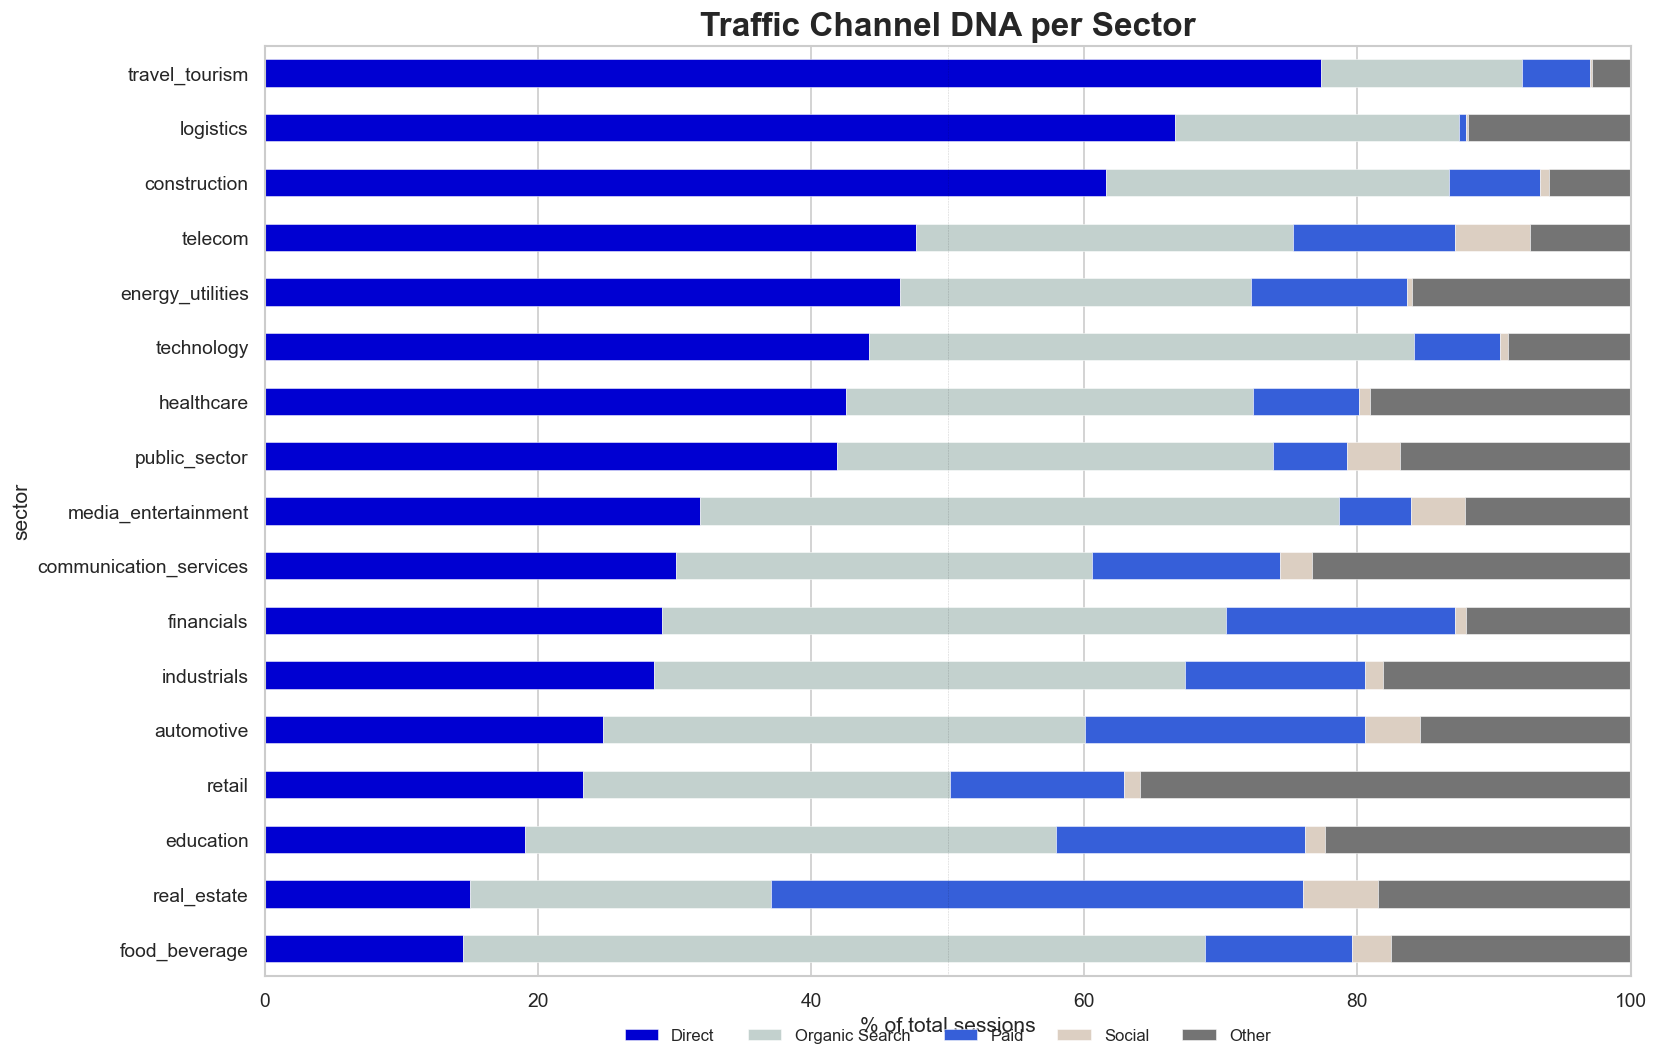

In [5]:
# 2.1 Channel Mix — Simplified (5 channels)
df_channels = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        CASE 
            WHEN t.session_channel_group = 'Organic Search' THEN 'Organic Search'
            WHEN t.session_channel_group = 'Direct' THEN 'Direct'
            WHEN t.session_channel_group IN ('Paid Search', 'Paid Social', 'Paid Shopping', 'Paid Video', 'Paid Other', 'Display') THEN 'Paid'
            WHEN t.session_channel_group IN ('Organic Social', 'Organic Video') THEN 'Social'
            ELSE 'Other'
        END AS channel,
        SUM(t.sessions) AS sessions
    FROM traffic_sources t
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
    GROUP BY sector, channel
""", conn)

pivot_ch = df_channels.pivot_table(index='sector', columns='channel', values='sessions', fill_value=0)
pivot_pct = pivot_ch.div(pivot_ch.sum(axis=1), axis=0) * 100

if 'Direct' in pivot_pct.columns:
    pivot_pct = pivot_pct.sort_values('Direct', ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))
channel_order = ['Direct', 'Organic Search', 'Paid', 'Social', 'Other']
channel_colors = {'Direct': '#0000D2', 'Organic Search': '#C3D1CE', 'Paid': '#365FD9',
                  'Social': '#DCCFC2', 'Other': '#747474'}
plot_cols = [c for c in channel_order if c in pivot_pct.columns]
colors = [channel_colors[c] for c in plot_cols]

pivot_pct[plot_cols].plot(kind='barh', stacked=True, ax=ax, color=colors,
                          edgecolor='white', linewidth=0.3)
ax.set_xlabel('% of total sessions')
ax.set_title('Traffic Channel DNA per Sector',
             fontweight='bold', fontsize=20)
ax.axvline(x=50, color='black', linewidth=0.3, linestyle='--', alpha=0.2)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.04), ncol=5, frameon=False, fontsize=10)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## 4. Device Split per Sector

Mobile-first vs desktop-dominant — bepaalt UX-strategie en optimalisatieprioriteiten.

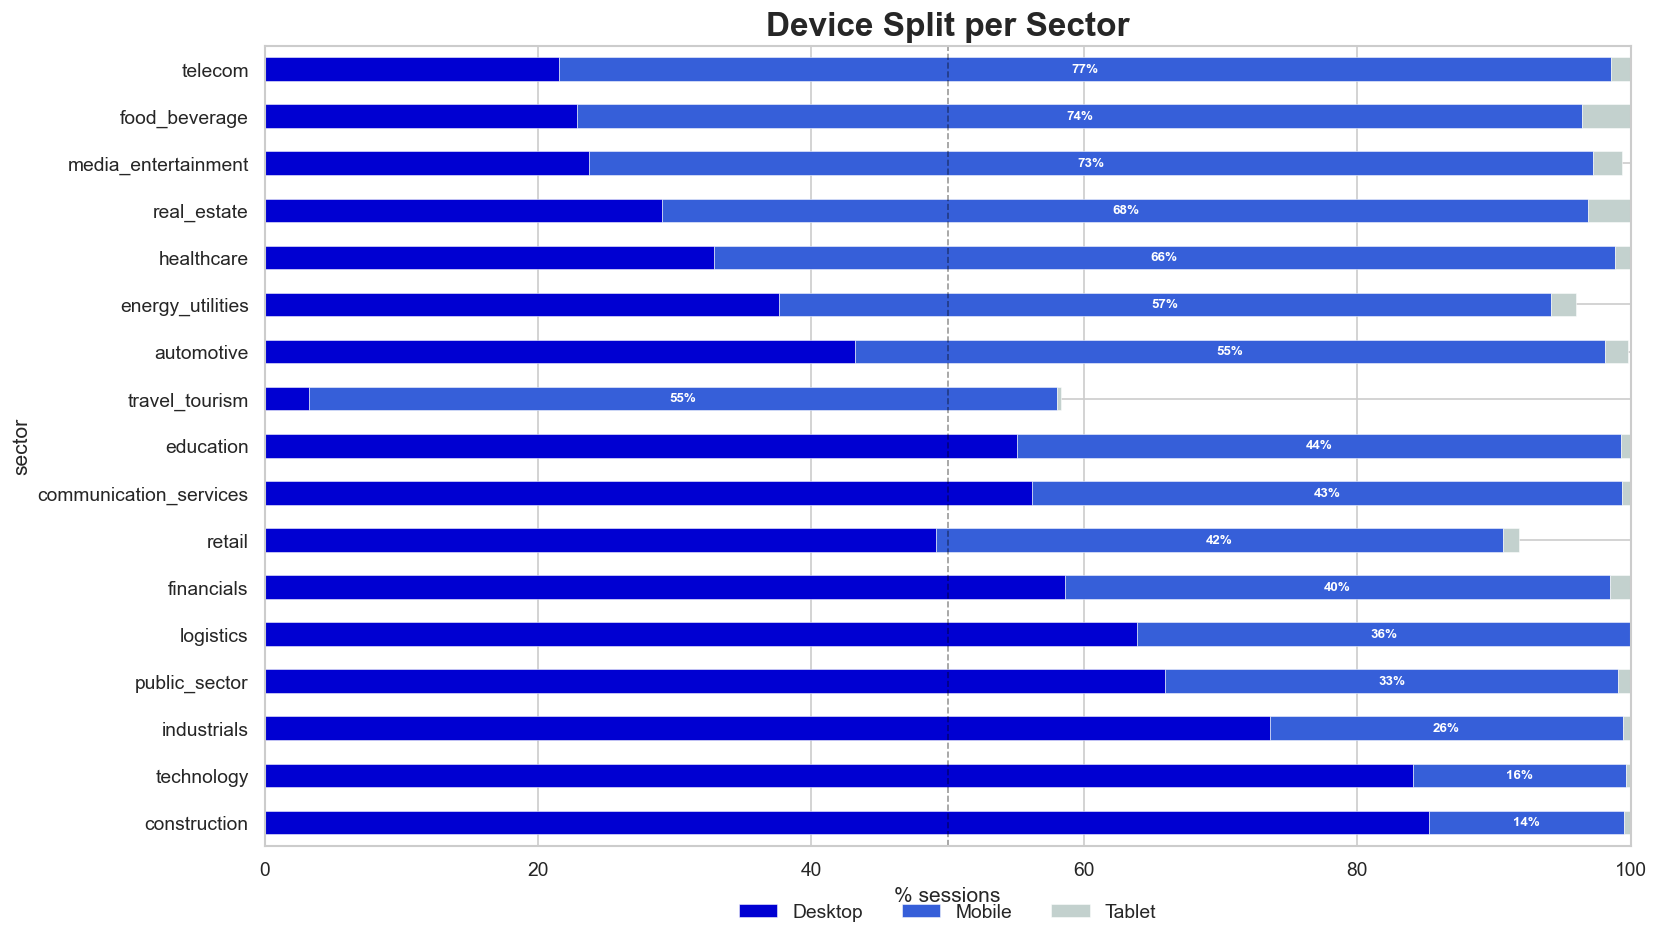

In [6]:
# 3.1 Device Split per Sector
df_device = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        CASE 
            WHEN g.device_category = 'desktop' THEN 'Desktop'
            WHEN g.device_category = 'mobile' THEN 'Mobile'
            WHEN g.device_category = 'tablet' THEN 'Tablet'
            ELSE 'Other'
        END AS device,
        SUM(g.sessions) AS sessions
    FROM geo_device g
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
    GROUP BY sector, device
""", conn)

pivot_dev = df_device.pivot_table(index='sector', columns='device', values='sessions', fill_value=0)
pivot_dev['total'] = pivot_dev.sum(axis=1)
pivot_dev['mobile_pct'] = pivot_dev.get('Mobile', 0) / pivot_dev['total'] * 100
pivot_dev = pivot_dev.sort_values('mobile_pct', ascending=True)

pivot_dev_pct = pivot_dev[['Desktop', 'Mobile', 'Tablet']].div(pivot_dev['total'], axis=0) * 100
pivot_dev_pct = pivot_dev_pct.fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
pivot_dev_pct[['Desktop', 'Mobile', 'Tablet']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#0000D2', '#365FD9', '#C3D1CE'], edgecolor='white', linewidth=0.3
)
ax.axvline(x=50, color='black', linewidth=1.0, linestyle='--', alpha=0.4)
ax.set_xlabel('% sessions')
ax.set_title('Device Split per Sector',
             fontweight='bold', fontsize=20)
ax.set_xlim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)

for i, (sector, row) in enumerate(pivot_dev_pct.iterrows()):
    mobile = row.get('Mobile', 0)
    desktop = row.get('Desktop', 0)
    if mobile > 8:
        ax.text(desktop + mobile/2, i, f'{mobile:.0f}%',
                va='center', ha='center', fontsize=8, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 5. Weekend Activity Drop-off

Food & Beverage is de enige sector die traffic wint op het weekend (+4%). Industrials verliest 63%.

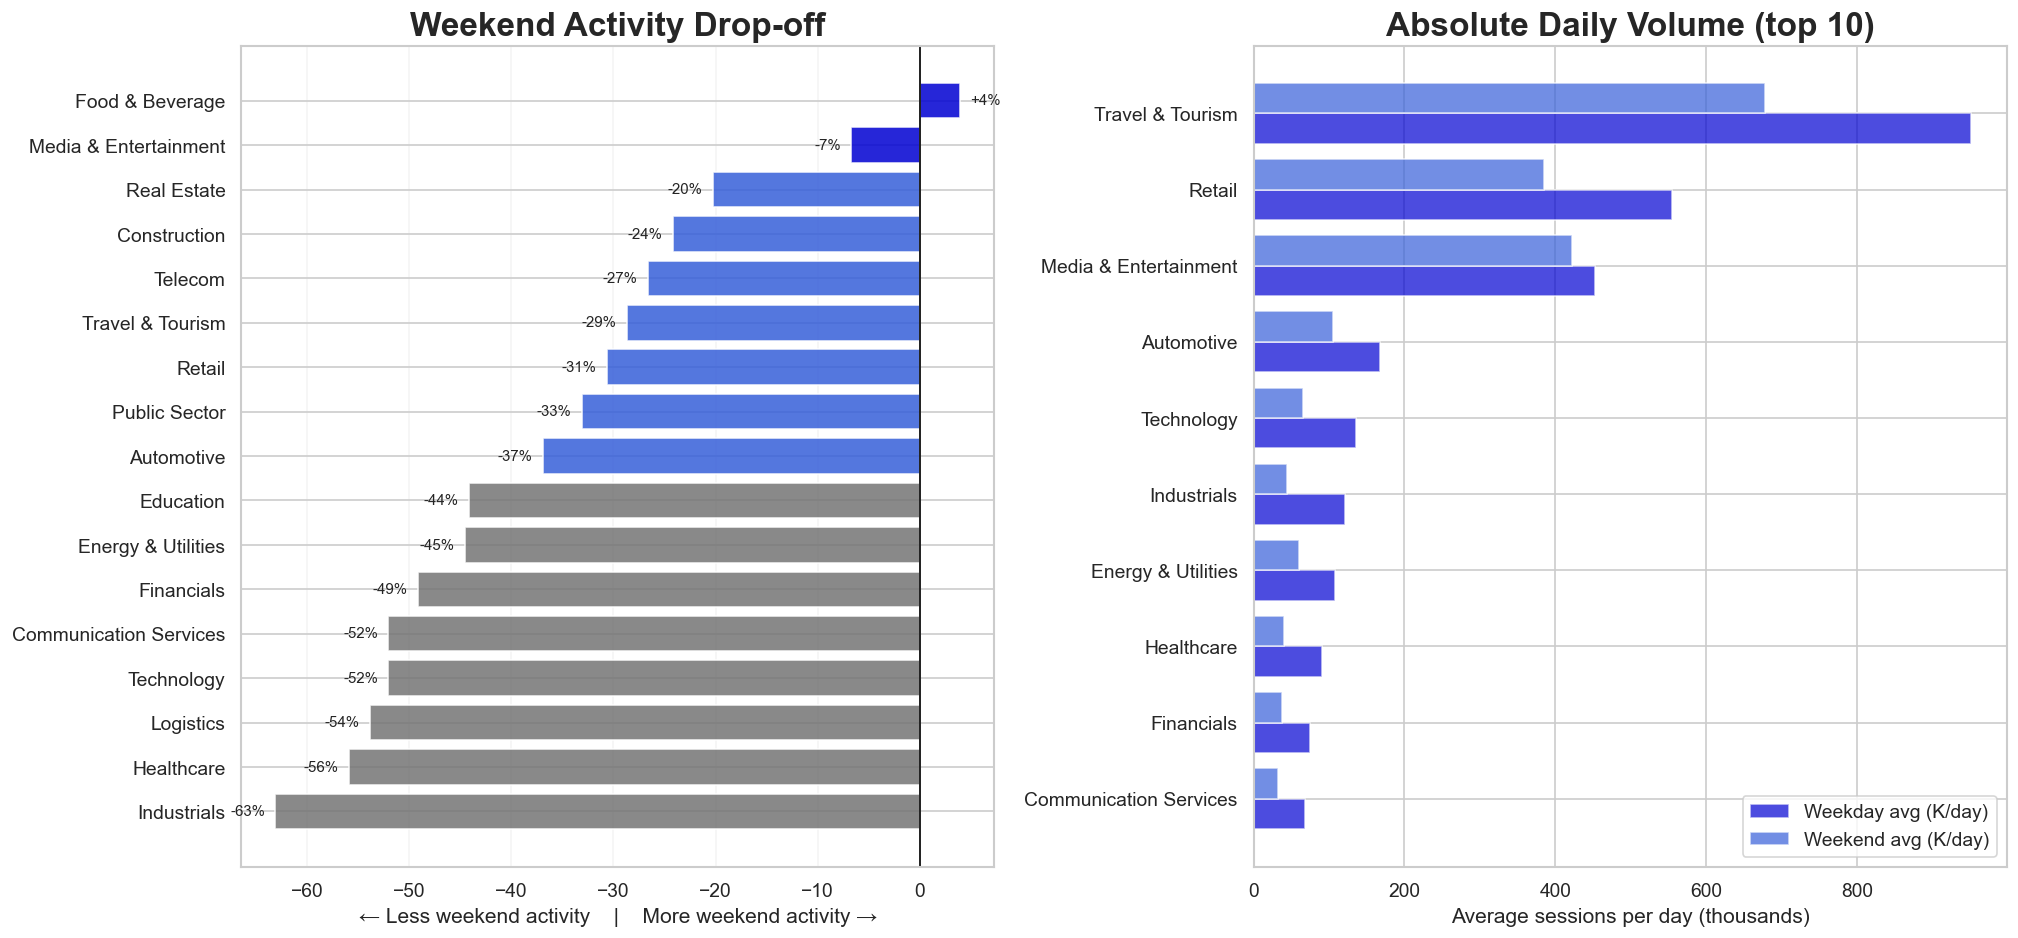

In [7]:
# 7.1 Weekend vs Weekday Activity + Absolute Context
df_daily = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        d.date,
        SUM(d.sessions) AS sessions
    FROM properties p
    JOIN daily_summary d USING (property_id)
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
    GROUP BY sector, d.date
""", conn)
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily['is_weekend'] = df_daily['date'].dt.dayofweek >= 5

df_wk = df_daily.groupby(['sector', 'is_weekend']).agg(
    avg_daily_sessions=('sessions', 'mean'),
    total_sessions=('sessions', 'sum'),
    n_days=('date', 'nunique')
).reset_index()

df_wk_pivot = df_wk.pivot_table(index='sector', columns='is_weekend', values='avg_daily_sessions')
df_wk_pivot.columns = ['weekday_daily', 'weekend_daily']

# Express as divergence from weekday: +2% means weekend is 2% higher, -63% means weekend has 63% less
df_wk_pivot['weekend_diff'] = (df_wk_pivot['weekend_daily'] - df_wk_pivot['weekday_daily']) / df_wk_pivot['weekday_daily'] * 100
df_wk_pivot = df_wk_pivot.sort_values('weekend_diff', ascending=True).reset_index()


# Pretty sector names
SECTOR_NAMES = {
    'food_beverage': 'Food & Beverage', 'media_entertainment': 'Media & Entertainment',
    'real_estate': 'Real Estate', 'construction': 'Construction', 'telecom': 'Telecom',
    'travel_tourism': 'Travel & Tourism', 'retail': 'Retail', 'public_sector': 'Public Sector',
    'automotive': 'Automotive', 'education': 'Education', 'energy_utilities': 'Energy & Utilities',
    'financials': 'Financials', 'communication_services': 'Communication Services',
    'technology': 'Technology', 'logistics': 'Logistics', 'healthcare': 'Healthcare',
    'industrials': 'Industrials',
}
df_wk_pivot['sector'] = df_wk_pivot['sector'].map(lambda s: SECTOR_NAMES.get(s, s))
df_abs = df_wk_pivot.sort_values('weekday_daily', ascending=True).tail(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 8))

# Left: diverging bar chart centered at 0
colors = [C['primary'] if d > -20 else C['secondary'] if d > -40 else C['mid_grey']
          for d in df_wk_pivot['weekend_diff']]
bars = ax1.barh(range(len(df_wk_pivot)), df_wk_pivot['weekend_diff'], color=colors, alpha=0.85)
ax1.set_yticks(range(len(df_wk_pivot)))
ax1.set_yticklabels(df_wk_pivot['sector'])
ax1.axvline(x=0, color=C['dark'], linewidth=1.2)
ax1.set_xlabel('\u2190 Less weekend activity    |    More weekend activity \u2192')
ax1.set_title('Weekend Activity Drop-off',
              fontweight='bold', fontsize=20)
ax1.grid(axis='x', alpha=0.2)

for bar, row in zip(bars, df_wk_pivot.itertuples()):
    val = row.weekend_diff
    ha = 'left' if val >= 0 else 'right'
    offset = 1 if val >= 0 else -1
    ax1.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha=ha, fontsize=9, color=C['dark'])

# Right: absolute volume context (top 10 by weekday volume)
y_pos = range(len(df_abs))
ax2.barh(y_pos, df_abs['weekday_daily'] / 1000, height=0.4,
         color=C['primary'], alpha=0.7, label='Weekday avg (K/day)')
ax2.barh([y + 0.4 for y in y_pos], df_abs['weekend_daily'] / 1000, height=0.4,
         color=C['secondary'], alpha=0.7, label='Weekend avg (K/day)')
ax2.set_yticks([y + 0.2 for y in y_pos])
ax2.set_yticklabels(df_abs['sector'])
ax2.set_xlabel('Average sessions per day (thousands)')
ax2.set_title('Absolute Daily Volume (top 10)',
              fontweight='bold', fontsize=20)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()



## 6. Conversion Rate per Kanaal × Sector

% sessies met ≥1 conversie-event. Altijd tussen 0% en 100%.

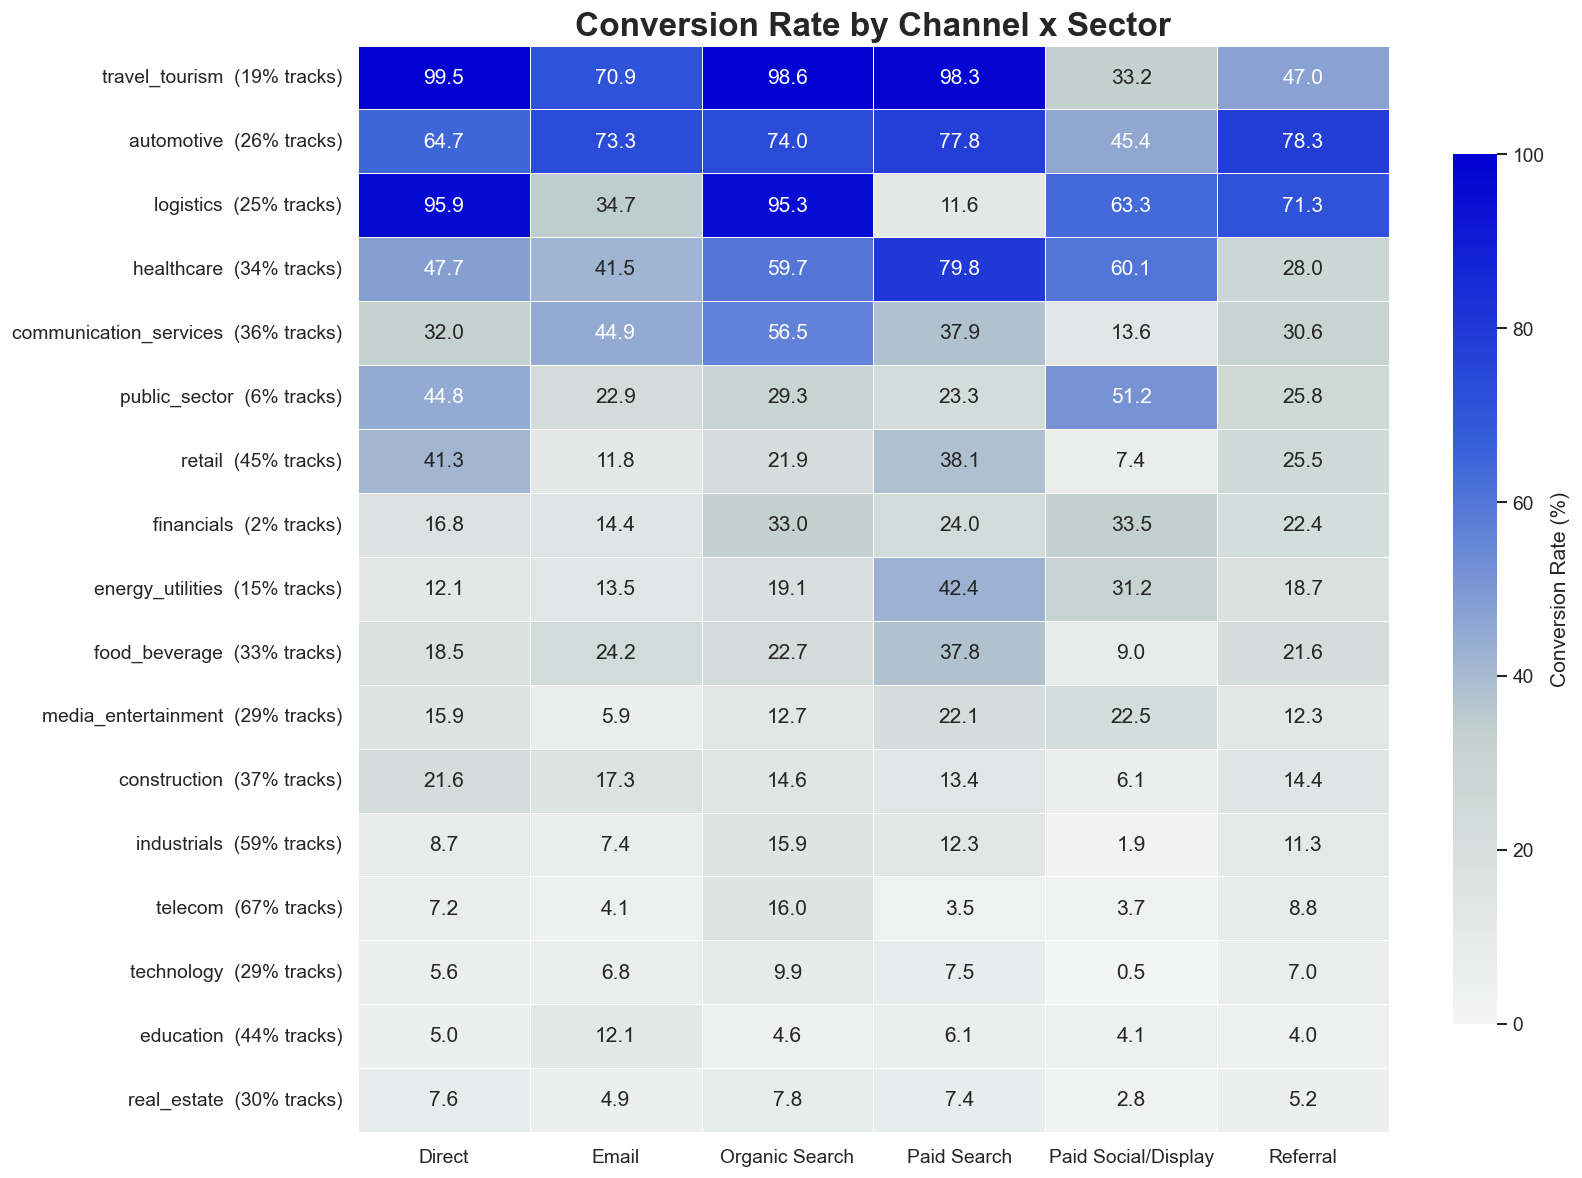


How to read: 27.6% = 27.6% of sessions in that channel/sector had at least one conversion.
Values are capped at 100% (impossible to exceed). Higher = more converting traffdezic.

'% tracks' = share of properties in that sector with conversion tracking configured.


In [8]:
# 8.1 Conversion Rate by Channel x Sector
# Fixed: uses MIN(conversions, sessions) / sessions = % sessions with ≥1 conversion (capped at 100%)
# Whale accounts INCLUDED — they're the aspirational benchmark.

df_ch_conv = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        CASE 
            WHEN t.session_channel_group = 'Organic Search' THEN 'Organic Search'
            WHEN t.session_channel_group = 'Direct' THEN 'Direct'
            WHEN t.session_channel_group IN ('Paid Search', 'Paid Shopping') THEN 'Paid Search'
            WHEN t.session_channel_group IN ('Paid Social', 'Display') THEN 'Paid Social/Display'
            WHEN t.session_channel_group = 'Email' THEN 'Email'
            WHEN t.session_channel_group = 'Referral' THEN 'Referral'
            ELSE NULL
        END AS channel,
        SUM(t.sessions) AS sessions,
        SUM(MIN(t.conversions, t.sessions)) AS converting_sessions
    FROM traffic_sources t
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
      AND p.account_name NOT IN ('De Mooiste Zwembaden', 'Logeren In Vlaanderen')
      AND t.property_id IN (
          SELECT property_id FROM traffic_sources GROUP BY property_id HAVING SUM(conversions) > 0
      )
    GROUP BY sector, channel
    HAVING channel IS NOT NULL AND SUM(t.sessions) > 100
""", conn)

df_ch_conv['conversion_rate'] = np.where(df_ch_conv['sessions'] > 0,
                                          df_ch_conv['converting_sessions'] / df_ch_conv['sessions'] * 100, 0)

# Tracking coverage per sector
tracking_coverage = pd.read_sql("""
    SELECT p.sector,
        COUNT(DISTINCT p.property_id) as total,
        COUNT(DISTINCT CASE WHEN sub.property_id IS NOT NULL THEN p.property_id END) as tracking
    FROM properties p
    LEFT JOIN (
        SELECT property_id FROM traffic_sources GROUP BY property_id HAVING SUM(conversions) > 0
    ) sub ON p.property_id = sub.property_id
    WHERE p.is_active = 1 AND p.sector NOT IN ('unknown', 'other')
    GROUP BY p.sector
""", conn)
tracking_coverage['pct'] = (tracking_coverage['tracking'] / tracking_coverage['total'] * 100).round(0)
coverage_map = dict(zip(tracking_coverage['sector'], tracking_coverage['pct']))

pivot_cvr = df_ch_conv.pivot_table(index='sector', columns='channel', values='conversion_rate', fill_value=0)
pivot_cvr = pivot_cvr.loc[pivot_cvr.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(pivot_cvr, annot=True, fmt='.1f', cmap=io_cmap, ax=ax,
            linewidths=0.5, linecolor='white', vmin=0, vmax=100,
            cbar_kws={'label': 'Conversion Rate (%)', 'shrink': 0.8})

ylabels = [f"{sector}  ({int(coverage_map.get(sector, 0))}% tracks)"
           for sector in pivot_cvr.index]
ax.set_yticklabels(ylabels, rotation=0)

ax.set_title('Conversion Rate by Channel x Sector',
             fontweight='bold', fontsize=20)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

print("\nHow to read: 27.6% = 27.6% of sessions in that channel/sector had at least one conversion.")
print("Values are capped at 100% (impossible to exceed). Higher = more converting traffdezic.")
print("\n'% tracks' = share of properties in that sector with conversion tracking configured.")

---
## 7. Sector Deep-Dive: Food & Beverage

34 accounts, 3.5M sessions. Herkenbare merken: LVBO, Spadel, Lotus Bakeries, Soda Stream.

In [9]:
SECTOR = 'food_beverage'  # <-- Change to any sector

# Reopen connection (allows re-running this cell independently)
conn = sqlite3.connect(Path('../data/ga4_data_lucas_final.db'))

# ─── Load property-level data for this sector ───────────────────────────────
df_props = pd.read_sql(f"""
    SELECT 
        p.property_id,
        p.property_name,
        p.account_name,
        p.account_id,
        SUM(d.sessions) AS sessions,
        SUM(d.engaged_sessions) AS engaged_sessions,
        AVG(d.engagement_rate) AS engagement_rate,
        AVG(d.average_session_duration) AS avg_duration,
        SUM(d.conversions) AS conversions,
        SUM(MIN(d.conversions, d.sessions)) AS converting_sessions,
        SUM(d.new_users) AS new_users,
        SUM(d.total_users) AS total_users
    FROM properties p
    JOIN daily_summary d USING (property_id)
    WHERE p.is_active = 1 AND p.sector = '{SECTOR}'
    GROUP BY p.property_id
    HAVING SUM(d.sessions) > 100
""", conn)

df_props['eng_rate'] = df_props['engaged_sessions'] / df_props['sessions'] * 100
df_props['cvr'] = np.where(df_props['sessions'] > 0, df_props['converting_sessions'] / df_props['sessions'] * 100, 0)
df_props['new_user_pct'] = df_props['new_users'] / df_props['total_users'] * 100

# Channel mix per property
df_prop_channels = pd.read_sql(f"""
    SELECT 
        t.property_id,
        CASE 
            WHEN t.session_channel_group = 'Organic Search' THEN 'Organic Search'
            WHEN t.session_channel_group = 'Direct' THEN 'Direct'
            WHEN t.session_channel_group IN ('Paid Search', 'Paid Social', 'Paid Shopping', 'Paid Video', 'Paid Other', 'Display') THEN 'Paid'
            WHEN t.session_channel_group IN ('Organic Social', 'Organic Video') THEN 'Social'
            ELSE 'Other'
        END AS channel,
        SUM(t.sessions) AS sessions
    FROM traffic_sources t
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 AND p.sector = '{SECTOR}'
    GROUP BY t.property_id, channel
""", conn)

# Pivot to get channel percentages per property
prop_ch_pivot = df_prop_channels.pivot_table(index='property_id', columns='channel', values='sessions', fill_value=0)
prop_ch_total = prop_ch_pivot.sum(axis=1)
prop_ch_pct = prop_ch_pivot.div(prop_ch_total, axis=0) * 100

# Merge channel data with property data
df_props = df_props.merge(prop_ch_pct, on='property_id', how='left').fillna(0)

# Sector KPIs
sector_kpi = df_kpi[df_kpi['sector'] == SECTOR].iloc[0]
sector_n = int(sector_kpi['accounts'])
sector_eng = sector_kpi['eng_rate']
sector_sessions = sector_kpi['sessions']

# Quartile assignment
df_props['eng_quartile'] = pd.qcut(df_props['eng_rate'], 4, labels=['Q4 (bottom)', 'Q3', 'Q2', 'Q1 (top)'])

print(f"{'='*60}")
print(f"  SECTOR DEEP-DIVE: {SECTOR.upper()}")
print(f"  {sector_n} accounts | {sector_sessions/1e6:.1f}M sessions | {sector_eng:.1f}% avg engagement")
print(f"  {len(df_props)} properties with >100 sessions loaded")
print(f"{'='*60}")

  SECTOR DEEP-DIVE: FOOD_BEVERAGE
  34 accounts | 3.5M sessions | 65.3% avg engagement
  68 properties with >100 sessions loaded


### 7a. Account Leaderboard

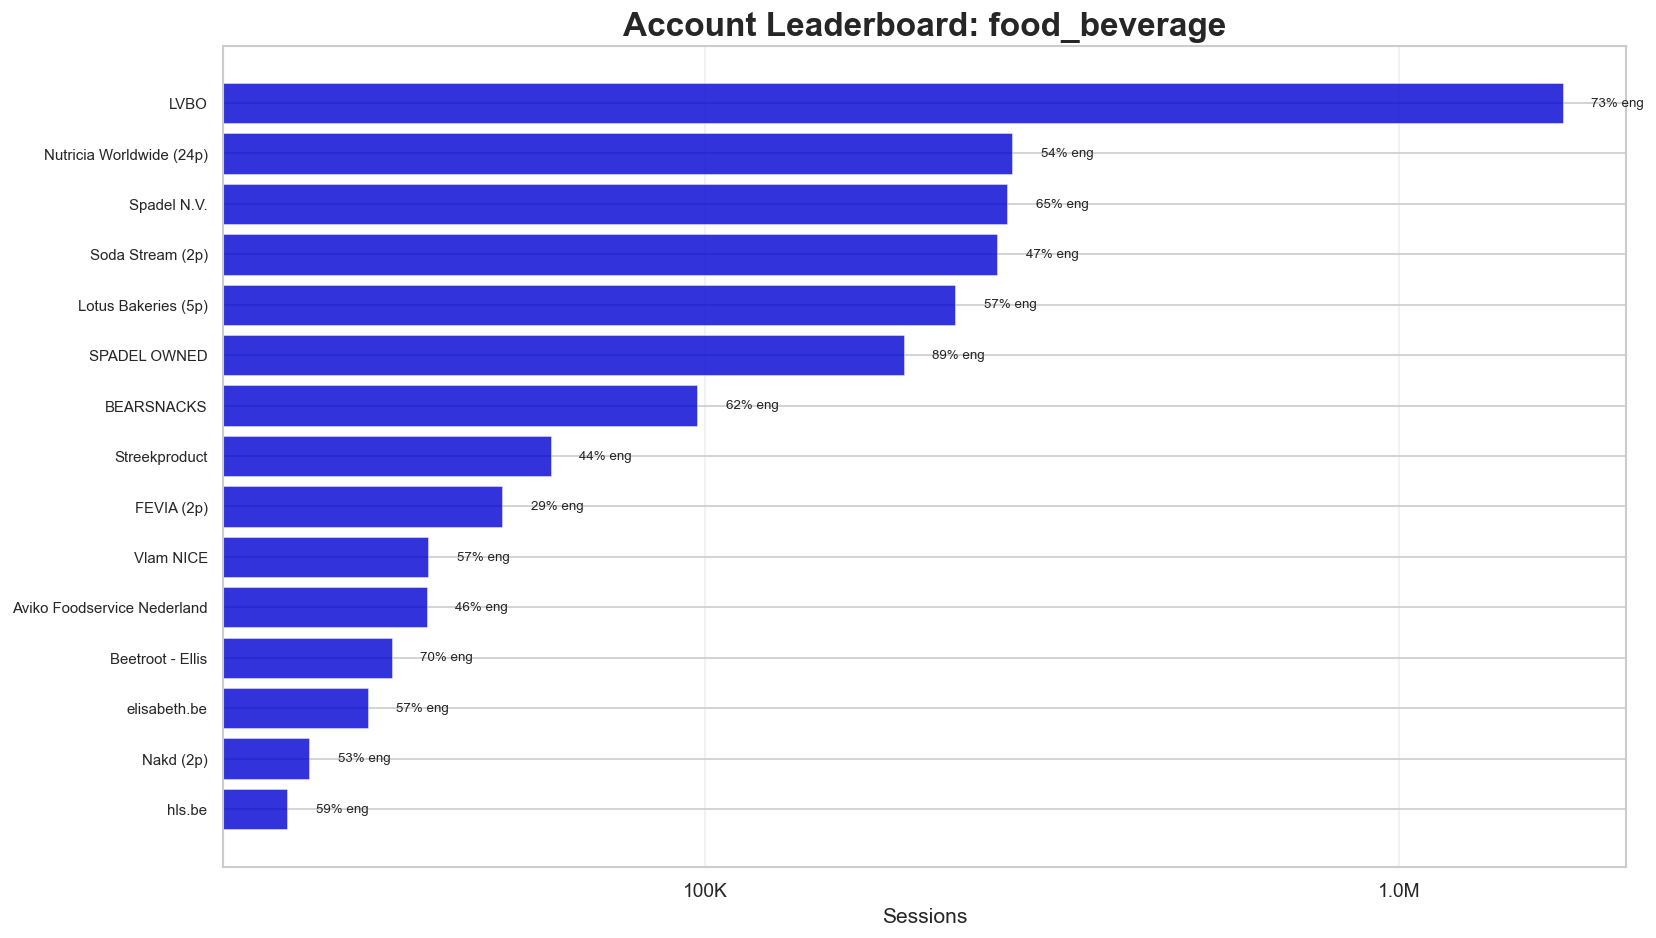


Top 5 accounts by sessions:
  LVBO                                  1,718,413 sessions  |  73% eng
  Nutricia Worldwide                      276,966 sessions  |  54% eng (24p)
  Spadel N.V.                             272,258 sessions  |  65% eng
  Soda Stream                             263,489 sessions  |  47% eng (2p)
  Lotus Bakeries                          229,339 sessions  |  57% eng (5p)

Long tail: 16 accounts with 168K sessions combined


In [10]:
# 9.0 Sector Leaderboard — Top 15 accounts + long tail summary
# Aggregated by account to avoid Nutricia x20 duplication, log scale for LVBO dominance

df_account_agg = df_props.groupby('account_name').agg(
    sessions=('sessions', 'sum'),
    engaged_sessions=('engaged_sessions', 'sum'),
    properties=('property_id', 'count')
).reset_index()
df_account_agg['eng_rate'] = df_account_agg['engaged_sessions'] / df_account_agg['sessions'] * 100
df_account_agg = df_account_agg.sort_values('sessions', ascending=False).reset_index(drop=True)

TOP_N = 15
df_top = df_account_agg.head(TOP_N).copy()
df_rest = df_account_agg.iloc[TOP_N:]

plot_data = df_top[['account_name', 'sessions', 'eng_rate', 'properties']].copy()
plot_data['label'] = plot_data.apply(
    lambda r: f"{r['account_name'][:25]} ({r['properties']}p)" if r['properties'] > 1 
    else r['account_name'][:28], axis=1)

plot_data = plot_data.sort_values('sessions', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))

colors = [C['primary'] for _, row in plot_data.iterrows()]

bars = ax.barh(range(len(plot_data)), plot_data['sessions'], color=colors, alpha=0.8,
               edgecolor='white', linewidth=0.3)

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['label'], fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Sessions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))
ax.set_title(f'Account Leaderboard: {SECTOR}',
             fontweight='bold', fontsize=20)
ax.grid(axis='x', alpha=0.3)

for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(row['sessions'] * 1.1, i,
            f"{row['eng_rate']:.0f}% eng",
            va='center', fontsize=8, color=C['dark'])

plt.tight_layout()
plt.show()

print(f"\nTop 5 accounts by sessions:")
for _, row in df_account_agg.head(5).iterrows():
    n_props = f" ({row['properties']}p)" if row['properties'] > 1 else ""
    print(f"  {row['account_name'][:35]:35s}  {row['sessions']:>10,.0f} sessions  |  {row['eng_rate']:.0f}% eng{n_props}")
print(f"\nLong tail: {len(df_rest)} accounts with {df_rest['sessions'].sum()/1e3:.0f}K sessions combined")


### 7b. Property Positioning — Waar sta jij?

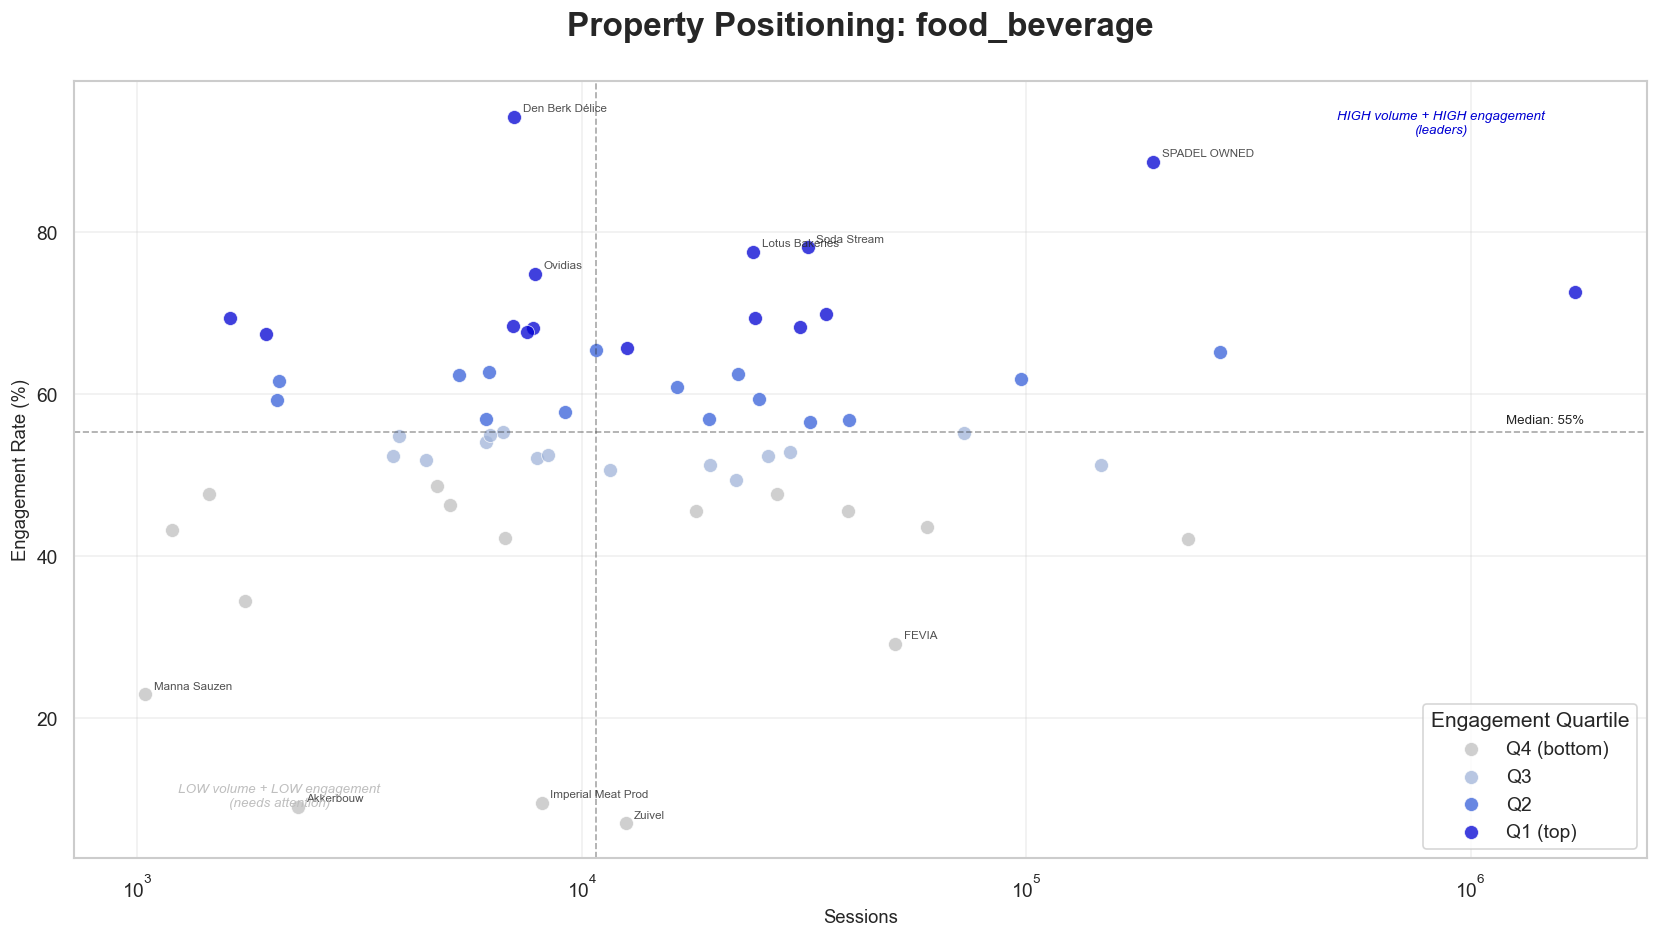


Quartile boundaries (engagement rate, n=61 properties with >1000 sessions):
  Q1 (top): 65.7% - 94.3% (15 properties)
  Q2: 56.6% - 65.5% (15 properties)
  Q3: 49.5% - 55.3% (15 properties)
  Q4 (bottom): 7.1% - 48.7% (16 properties)

  7 properties excluded (< 1000 sessions) — too small for meaningful comparison


In [11]:
# 9.1 Property Positioning: "Where do you sit among peers?"
# Scatter: X = sessions (log), Y = engagement rate. Min 1000 sessions for meaningful comparison.

MIN_SESSIONS = 1000
df_position = df_props[df_props['sessions'] >= MIN_SESSIONS].copy()

if len(df_position) < 10:
    df_position = df_props.copy()
    min_label = 100
else:
    min_label = MIN_SESSIONS

df_position['eng_quartile'] = pd.qcut(df_position['eng_rate'], 4, labels=['Q4 (bottom)', 'Q3', 'Q2', 'Q1 (top)'])

fig, ax = plt.subplots(figsize=(14, 8))

q_colors = {'Q1 (top)': '#0000D2', 'Q2': '#365FD9', 'Q3': '#A0B4D9', 'Q4 (bottom)': '#BFBFBF'}
for q in ['Q4 (bottom)', 'Q3', 'Q2', 'Q1 (top)']:
    mask = df_position['eng_quartile'] == q
    ax.scatter(df_position.loc[mask, 'sessions'], df_position.loc[mask, 'eng_rate'],
              s=70, alpha=0.75, color=q_colors[q], label=q, edgecolors='white', linewidth=0.5)

top5 = df_position.nlargest(5, 'eng_rate')
bot5 = df_position.nsmallest(5, 'eng_rate')
for _, row in pd.concat([top5, bot5]).iterrows():
    name = row['account_name'][:18] if isinstance(row['account_name'], str) else '?'
    ax.annotate(name, (row['sessions'], row['eng_rate']),
               fontsize=7, alpha=0.8, ha='left',
               xytext=(5, 3), textcoords='offset points')

med_eng = df_position['eng_rate'].median()
med_sess = df_position['sessions'].median()
ax.axhline(y=med_eng, color=C['dark'], linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(x=med_sess, color=C['dark'], linestyle='--', alpha=0.4, linewidth=1)
ax.text(df_position['sessions'].max() * 0.7, med_eng + 1, f'Median: {med_eng:.0f}%', fontsize=8, color=C['dark'])

ax.set_xscale('log')
ax.set_xlabel('Sessions', fontsize=11)
ax.set_ylabel('Engagement Rate (%)', fontsize=11)
ax.set_title(f'Property Positioning: {SECTOR}\n',
             fontweight='bold', fontsize=20)
ax.legend(title='Engagement Quartile', loc='lower right')
ax.grid(alpha=0.3)

ax.text(df_position['sessions'].max() * 0.5, df_position['eng_rate'].max() - 2,
        'HIGH volume + HIGH engagement\n(leaders)', fontsize=8, ha='center', style='italic', color=C['primary'])
ax.text(df_position['sessions'].min() * 2, df_position['eng_rate'].min() + 2,
        'LOW volume + LOW engagement\n(needs attention)', fontsize=8, ha='center', style='italic', color='#BFBFBF')

plt.tight_layout()
plt.show()

print(f"\nQuartile boundaries (engagement rate, n={len(df_position)} properties with >{min_label} sessions):")
for q in ['Q1 (top)', 'Q2', 'Q3', 'Q4 (bottom)']:
    subset = df_position[df_position['eng_quartile'] == q]['eng_rate']
    print(f"  {q}: {subset.min():.1f}% - {subset.max():.1f}% ({len(subset)} properties)")
excluded = len(df_props) - len(df_position)
if excluded > 0:
    print(f"\n  {excluded} properties excluded (< {min_label} sessions) — too small for meaningful comparison")

### 7c. Wat de Top Quartile Anders Doet

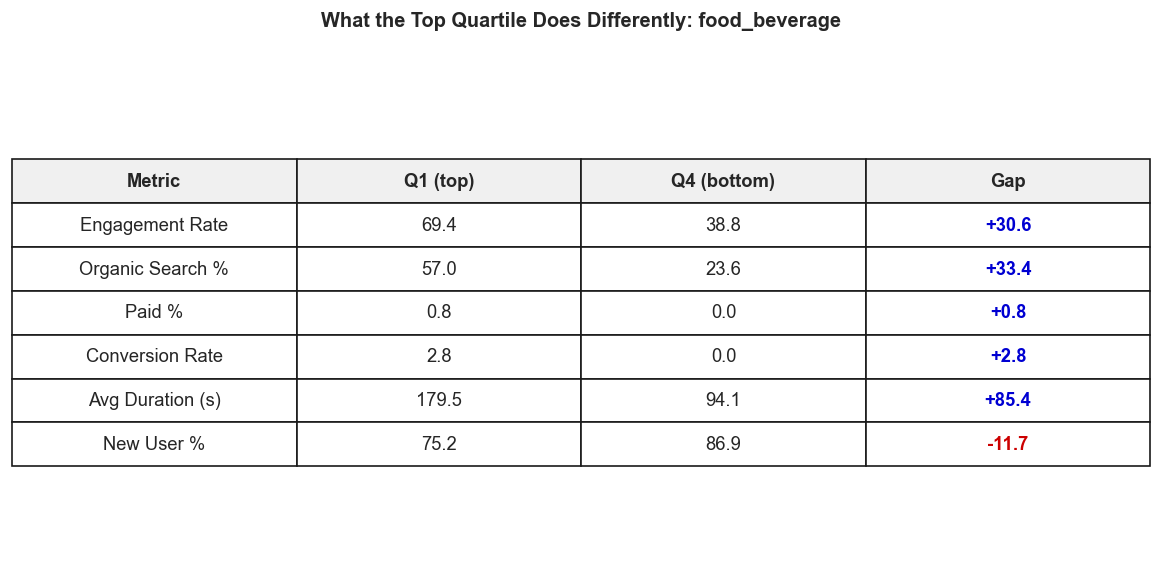


Key differences in food_beverage (top vs bottom quartile):
  - Engagement Rate: 30.6 higher
  - Organic Search %: 33.4 higher
  - Paid %: 0.8 higher
  - Conversion Rate: 2.8 higher
  - Avg Duration (s): 85.4 higher
  - New User %: 11.7 lower


In [12]:
# 9.4 "What separates the top quartile?" — Table comparison
# Radar removed: table communicates the same info more clearly

metrics_table = {
    'Engagement Rate': 'eng_rate',
    'Organic Search %': 'Organic Search' if 'Organic Search' in df_props.columns else None,
    'Paid %': 'Paid' if 'Paid' in df_props.columns else None,
    'Conversion Rate': 'cvr',
    'Avg Duration (s)': 'avg_duration',
    'New User %': 'new_user_pct',
}
metrics_table = {k: v for k, v in metrics_table.items() if v is not None and v in df_props.columns}

top_q = df_props[df_props['eng_quartile'] == 'Q1 (top)']
bot_q = df_props[df_props['eng_quartile'] == 'Q4 (bottom)']

table_data = []
for label, col in metrics_table.items():
    raw_top = top_q[col].median()
    raw_bot = bot_q[col].median()
    diff = raw_top - raw_bot
    diff_str = f'+{diff:.1f}' if diff > 0 else f'{diff:.1f}'
    table_data.append([label, f'{raw_top:.1f}', f'{raw_bot:.1f}', diff_str])

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

table = ax.table(cellText=table_data,
                 colLabels=['Metric', 'Q1 (top)', 'Q4 (bottom)', 'Gap'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.0)

# Color the Gap column
for i in range(len(table_data)):
    cell = table[i+1, 3]
    val = float(table_data[i][3].replace('+', ''))
    cell.set_text_props(color=C['primary'] if val > 0 else '#CC0000', fontweight='bold')

# Bold headers
for j in range(4):
    table[0, j].set_text_props(fontweight='bold')
    table[0, j].set_facecolor('#f0f0f0')

ax.set_title(f'What the Top Quartile Does Differently: {SECTOR}',
             fontweight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

print(f"\nKey differences in {SECTOR} (top vs bottom quartile):")
for row in table_data:
    val = float(row[3].replace('+', ''))
    if abs(val) > 0.5:
        direction = "higher" if val > 0 else "lower"
        print(f"  - {row[0]}: {abs(val):.1f} {direction}")


### 7d. E-Commerce Funnel

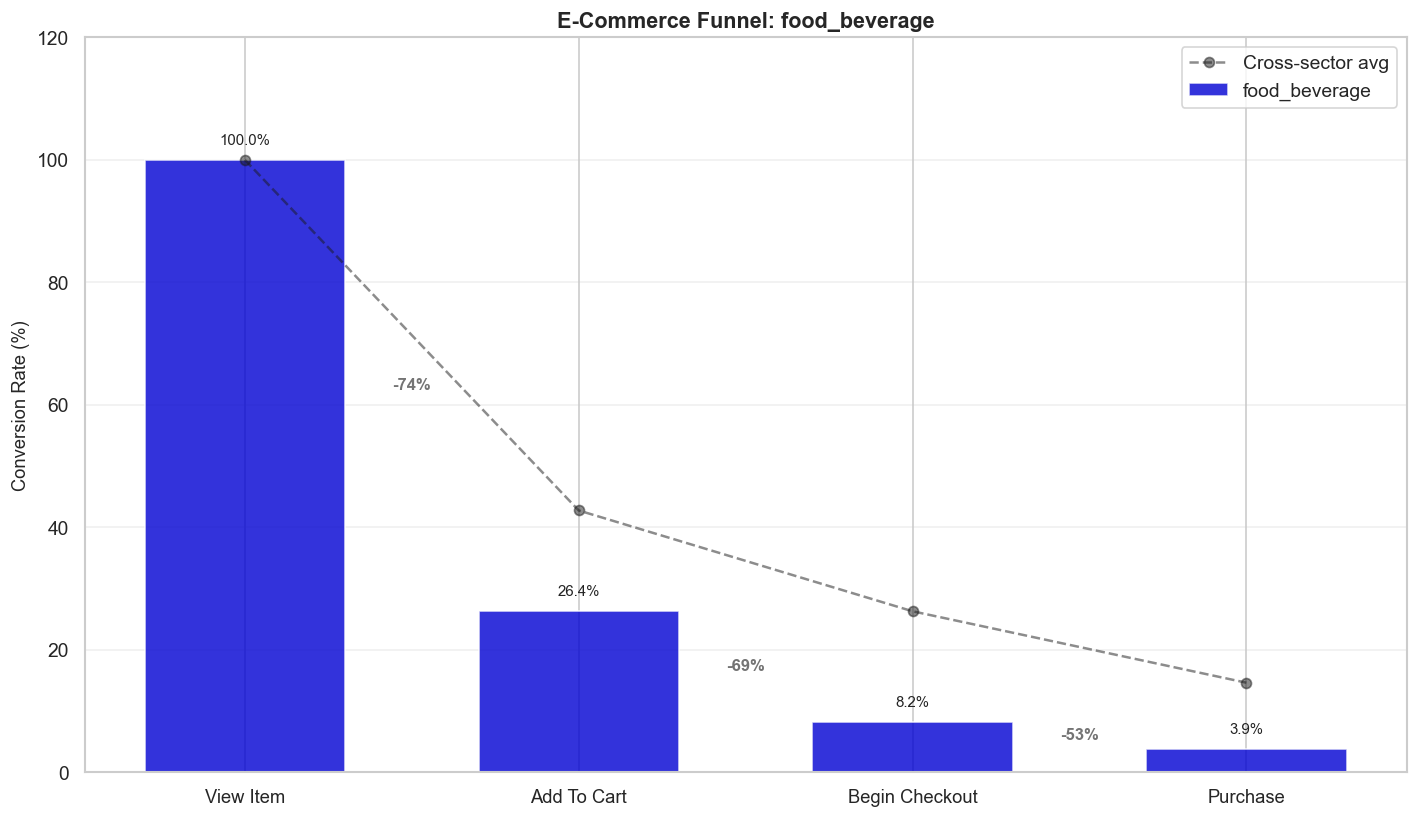


Funnel summary for food_beverage:
  Data coverage: 8/68 properties (12%) have e-commerce events
  View -> Cart:         26.4%
  Cart -> Checkout:     31.2%
  Checkout -> Purchase: 47.0%
  Overall (view -> purchase): 3.86%


NameError: name 'below_avg' is not defined

In [13]:
# 9.9 E-Commerce Funnel — with data coverage disclosure and explicit benchmark comparison
FUNNEL_STEPS = ['view_item', 'add_to_cart', 'begin_checkout', 'purchase']

df_funnel_all = pd.read_sql("""
    SELECT 
        COALESCE(p.sector, 'other') AS sector,
        e.event_name,
        SUM(e.event_count) AS event_count
    FROM ga4_events e
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 
      AND p.sector NOT IN ('unknown', 'other')
      AND e.event_name IN ('view_item', 'add_to_cart', 'begin_checkout', 'purchase')
    GROUP BY p.sector, e.event_name
""", conn)

# Data coverage: how many properties in this sector have e-commerce events?
n_ecom_props = pd.read_sql(f"""
    SELECT COUNT(DISTINCT e.property_id) as n
    FROM ga4_events e
    JOIN properties p USING (property_id)
    WHERE p.is_active = 1 AND p.sector = '{SECTOR}'
      AND e.event_name IN ('view_item', 'add_to_cart', 'begin_checkout', 'purchase')
      AND e.event_count > 0
""", conn).iloc[0, 0]

df_sector_funnel = df_funnel_all[df_funnel_all['sector'] == SECTOR].copy()
df_sector_funnel['event_name'] = pd.Categorical(df_sector_funnel['event_name'], categories=FUNNEL_STEPS, ordered=True)
df_sector_funnel = df_sector_funnel.sort_values('event_name').reset_index(drop=True)

df_cross_funnel = df_funnel_all.groupby('event_name')['event_count'].sum().reset_index()
df_cross_funnel['event_name'] = pd.Categorical(df_cross_funnel['event_name'], categories=FUNNEL_STEPS, ordered=True)
df_cross_funnel = df_cross_funnel.sort_values('event_name').reset_index(drop=True)

if len(df_sector_funnel) >= 2:
    top_step = df_sector_funnel['event_count'].iloc[0]
    df_sector_funnel['pct'] = df_sector_funnel['event_count'] / top_step * 100
    cross_top = df_cross_funnel['event_count'].iloc[0]
    df_cross_funnel['pct'] = df_cross_funnel['event_count'] / cross_top * 100

    fig, ax = plt.subplots(figsize=(12, 7))
    step_labels = [s.replace('_', ' ').title() for s in FUNNEL_STEPS]
    x = range(len(df_sector_funnel))

    bars = ax.bar(x, df_sector_funnel['pct'], color=C['primary'], alpha=0.8, width=0.6, label=SECTOR)
    cross_vals = [df_cross_funnel[df_cross_funnel['event_name'] == s]['pct'].values[0]
                  if s in df_cross_funnel['event_name'].values else 0
                  for s in df_sector_funnel['event_name']]
    ax.plot(x, cross_vals, 'k--o', linewidth=1.5, markersize=6, alpha=0.5, label='Cross-sector avg')

    ax.set_xticks(x)
    ax.set_xticklabels(step_labels, fontsize=11)
    ax.set_ylabel('Conversion Rate (%)', fontsize=11)
    ax.set_title(f'E-Commerce Funnel: {SECTOR}',
                 fontweight='bold', fontsize=13)
    ax.legend(loc='upper right')

    for i, row in enumerate(df_sector_funnel.itertuples()):
        ax.text(i, row.pct + 2, f'{row.pct:.1f}%',
                ha='center', va='bottom', fontsize=9, color=C['dark'])
        if i > 0:
            prev = df_sector_funnel['event_count'].iloc[i-1]
            drop = (1 - row.event_count / prev) * 100
            mid_y = (df_sector_funnel['pct'].iloc[i-1] + row.pct) / 2
            ax.annotate(f'-{drop:.0f}%', xy=(i - 0.5, mid_y),
                       fontsize=10, fontweight='bold', color=C['accent'], ha='center', va='center')



    ax.set_ylim(0, 120)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    if len(df_sector_funnel) == 4:
        overall_cvr = df_sector_funnel['event_count'].iloc[3] / df_sector_funnel['event_count'].iloc[0] * 100
        print(f"\nFunnel summary for {SECTOR}:")
        print(f"  Data coverage: {n_ecom_props}/{len(df_props)} properties ({n_ecom_props/len(df_props)*100:.0f}%) have e-commerce events")
        print(f"  View -> Cart:         {df_sector_funnel['event_count'].iloc[1]/df_sector_funnel['event_count'].iloc[0]*100:.1f}%")
        print(f"  Cart -> Checkout:     {df_sector_funnel['event_count'].iloc[2]/df_sector_funnel['event_count'].iloc[1]*100:.1f}%")
        print(f"  Checkout -> Purchase: {df_sector_funnel['event_count'].iloc[3]/df_sector_funnel['event_count'].iloc[2]*100:.1f}%")
        print(f"  Overall (view -> purchase): {overall_cvr:.2f}%")
        if below_avg:
            print(f"\n  Note: {SECTOR} underperforms the cross-sector average at every step.")
            print(f"  The -74% View->Cart drop may indicate tracking gaps (missing add_to_cart events)")
            print(f"  or genuinely lower purchase intent (browsing recipes vs. buying products).")
else:
    print(f"Insufficient funnel data for {SECTOR}")

In [ ]:
# conn.close()  — removed so cells can be re-run independently


Done.
